### Question Shuffle

In [5]:
[3][-1]

3

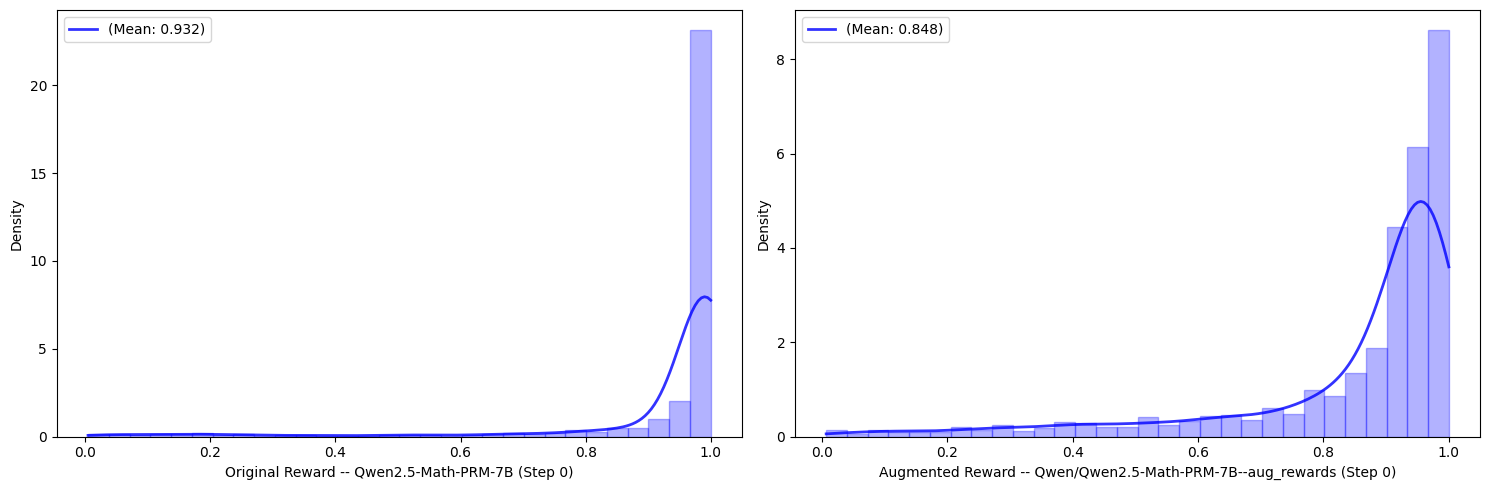

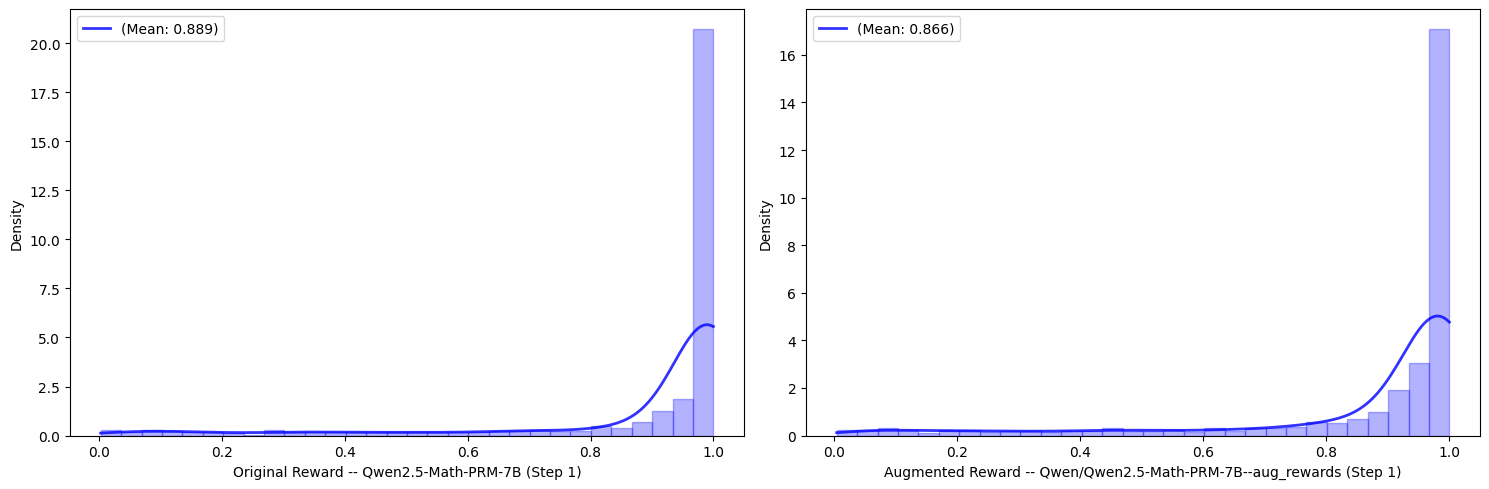

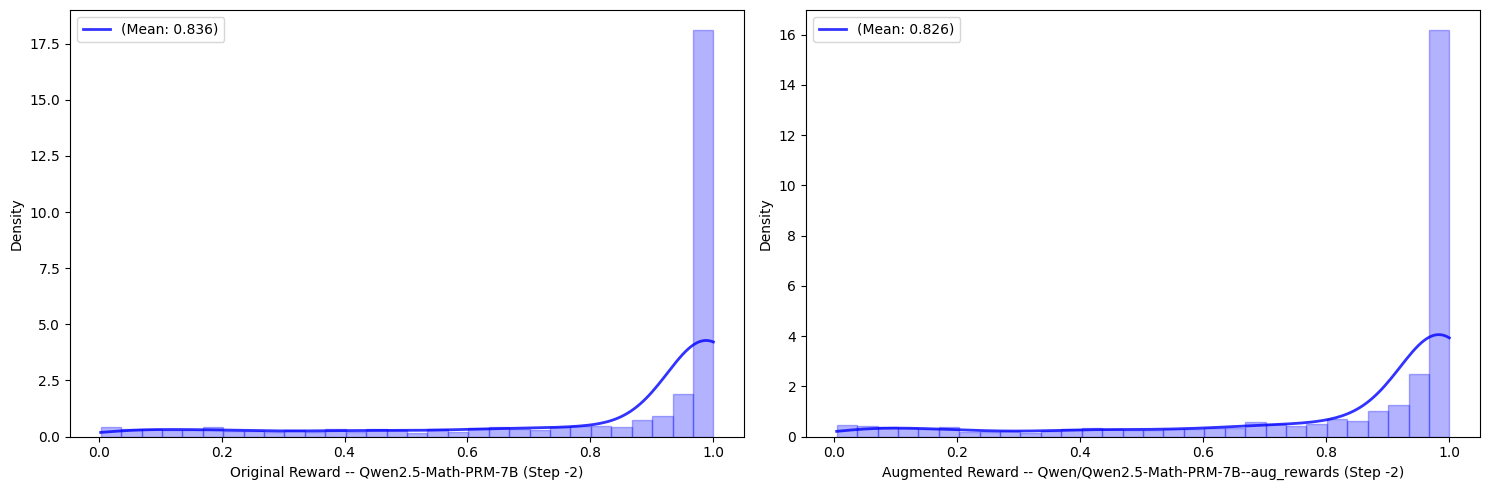

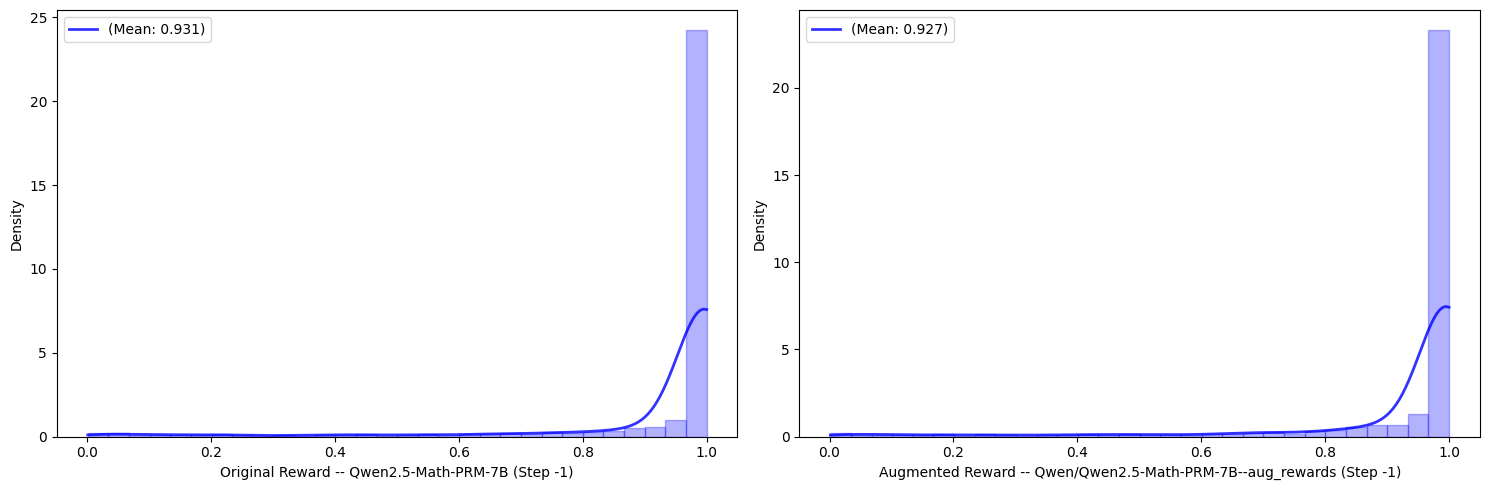

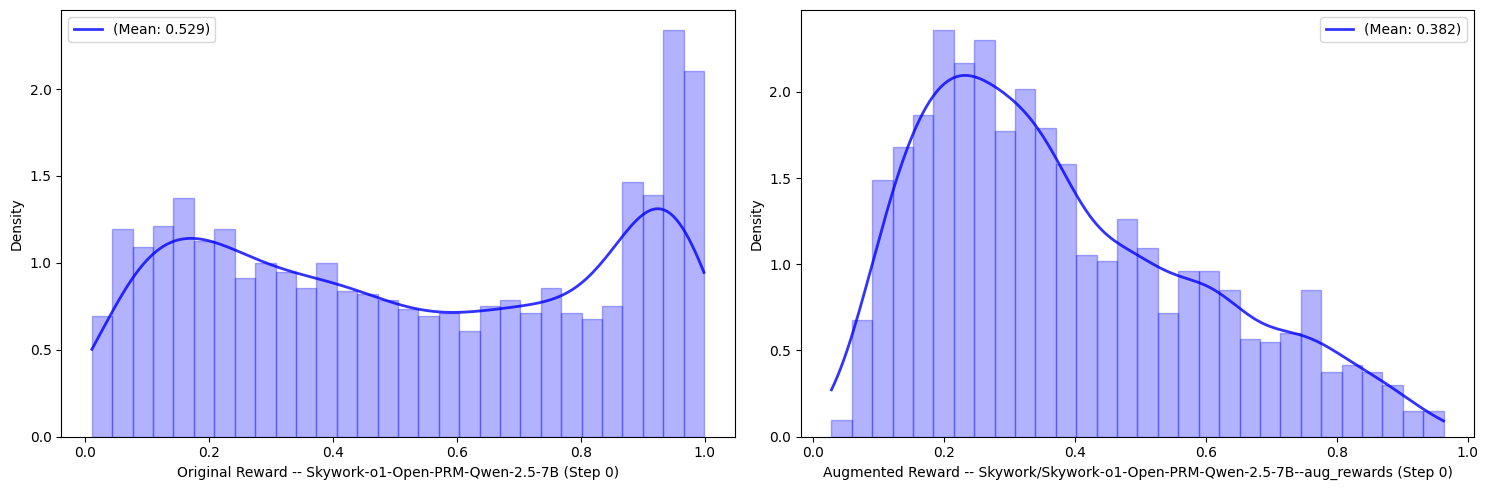

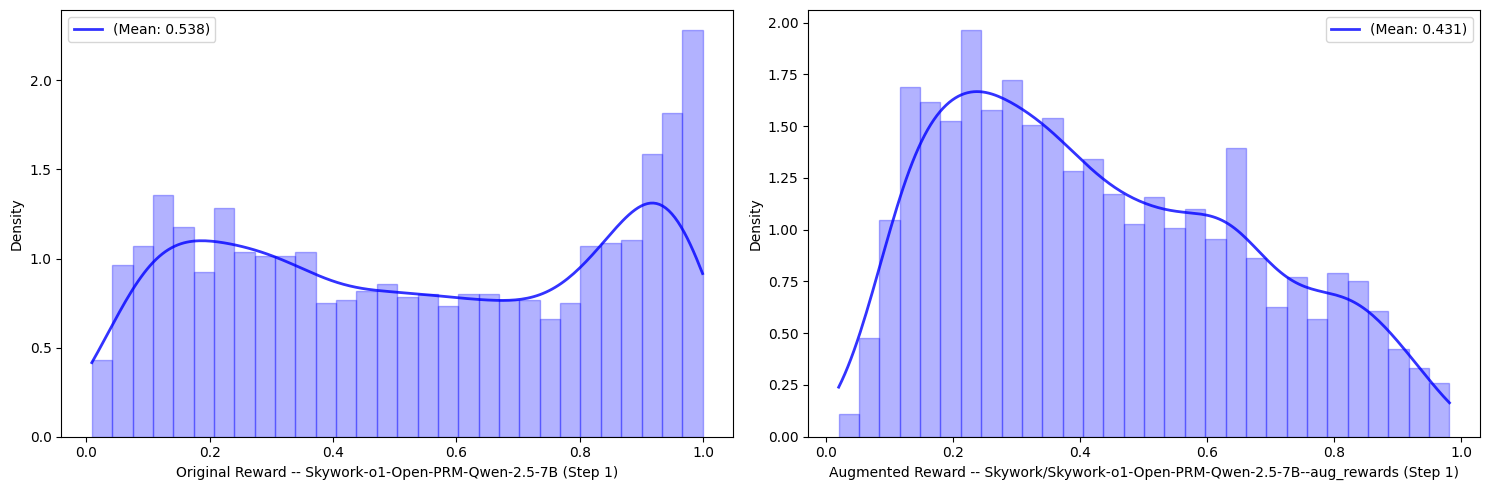

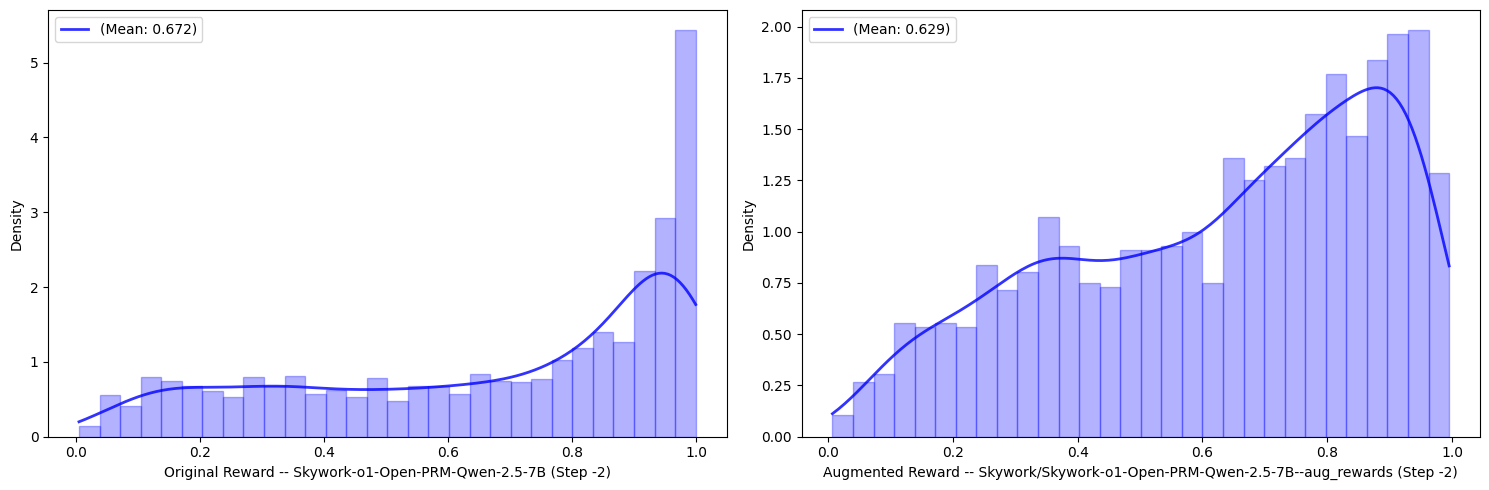

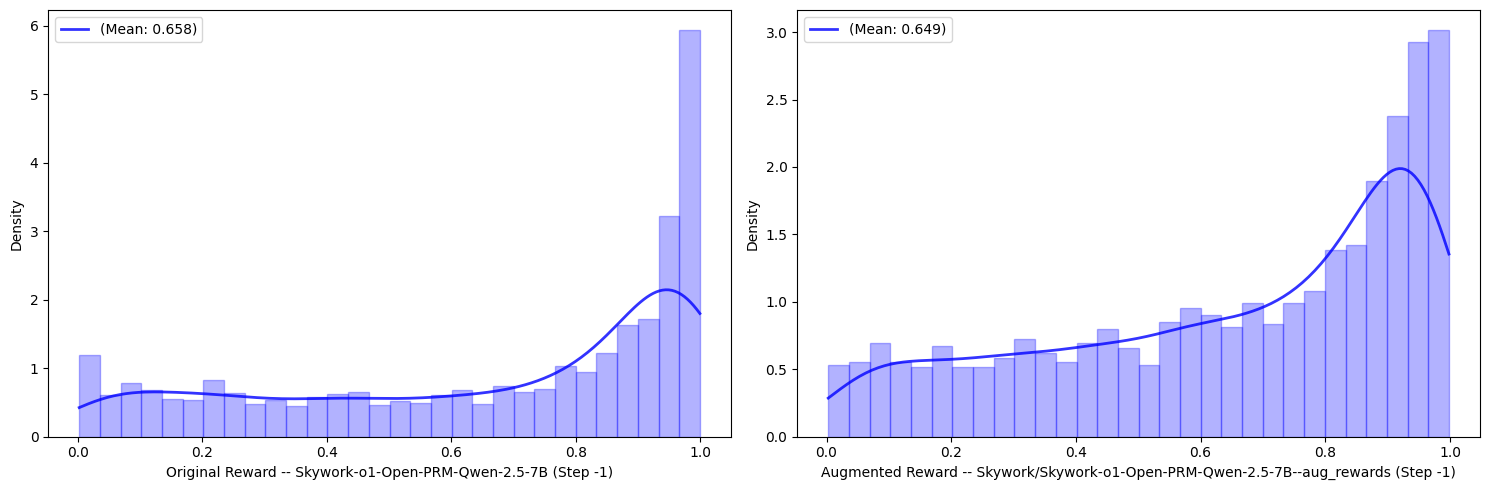

In [6]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

colors = ['blue', 'green', 'red', 'purple']
df = pd.read_parquet(f"attack.parquet")
for model in (["Qwen2.5-Math-PRM-7B", "Qwen/Qwen2.5-Math-PRM-7B--aug_rewards"], ["Skywork-o1-Open-PRM-Qwen-2.5-7B", "Skywork/Skywork-o1-Open-PRM-Qwen-2.5-7B--aug_rewards"]):
    for step_num in [0, 1, -2, -1]:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
        
        # for i, dataset in enumerate(["gsm8k", "math", "olympiadbench", "omnimath"]):
        for i in range(1):
        #     df_sample = df[df["split"] == dataset]
            df_sample = df
            df_sample = df_sample[df_sample["final_answer_correct"] == True]

            original_rewards = df_sample[model[0]].apply(lambda x: x[step_num]).to_numpy()
            augmented_rewards = df_sample[model[1]].apply(lambda x: x[step_num]).to_numpy()

            # Original plot
            ax1.hist(original_rewards, bins=30, density=True, alpha=0.3,
                    edgecolor=colors[i], color=colors[i])
            kde = stats.gaussian_kde(original_rewards)
            x_range = np.linspace(original_rewards.min(), original_rewards.max(), 200)
            ax1.plot(x_range, kde(x_range), color=colors[i], lw=2, alpha=0.8,
                    label=f'(Mean: {original_rewards.mean():.3f})')

            # Augmented plot  
            ax2.hist(augmented_rewards, bins=30, density=True, alpha=0.3,
                    edgecolor=colors[i], color=colors[i])
            kde = stats.gaussian_kde(augmented_rewards)
            x_range = np.linspace(augmented_rewards.min(), augmented_rewards.max(), 200)
            ax2.plot(x_range, kde(x_range), color=colors[i], lw=2, alpha=0.8,
                    label=f'(Mean: {augmented_rewards.mean():.3f})')

        ax1.set_xlabel(f'Original Reward -- {model[0]} (Step {step_num})')
        ax1.set_ylabel('Density')
        ax1.legend()

        ax2.set_xlabel(f'Augmented Reward -- {model[1]} (Step {step_num})')
        ax2.set_ylabel('Density')
        ax2.legend()

        plt.tight_layout()
        plt.show()


Color mapping for splits:
--------------------------------------------------------------------------------
gsm8k: red
question_removal: Number of equivalent samples: 3400 out of 3400
question_removal: Number of filtered samples: 1179 out of 3400


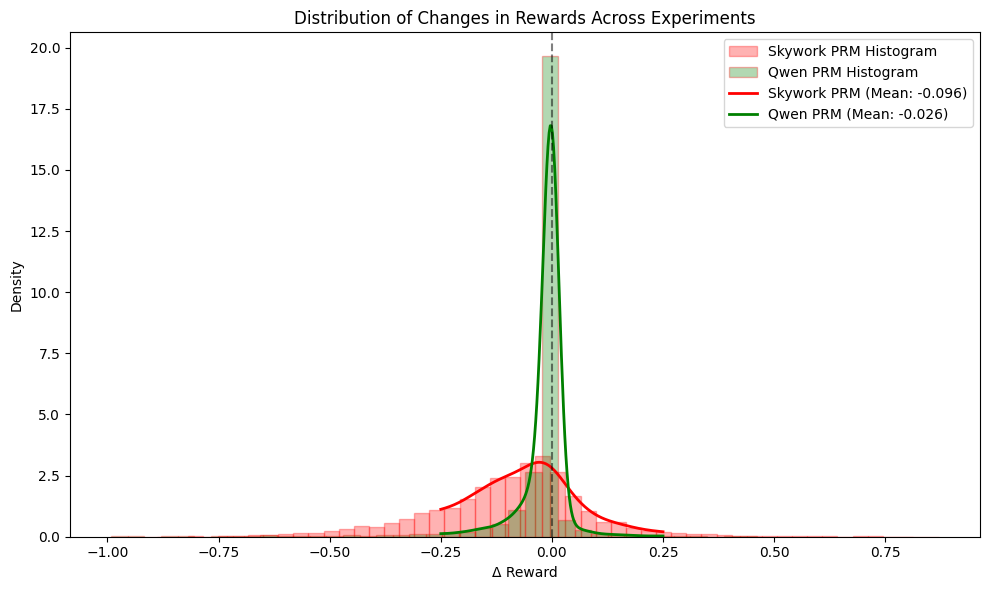

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import pandas as pd

# List of experiments to compare
experiment_names = ["question_removal"]
splits = ["gsm8k"]
colors = ['red']  # Different color for each experiment
# Print which color corresponds to which split
print("\nColor mapping for splits:")
print("-" * 80)
for i, split in enumerate(splits):
    print(f"{split}: {colors[i]}")

plt.figure(figsize=(10, 6))

# Process each experiment
for i, split in enumerate(splits):
    experiment_name = "question_removal"
    try:
        df_sample = pd.read_parquet(f"attack.parquet")
        # Filter data
        df_filtered = df_sample
        # df_filtered = df_sample[df_sample["equivalence"] == True]
        print(f"{experiment_name}: Number of equivalent samples: {len(df_filtered)} out of {len(df_sample)}")
        # df_filtered = df_filtered[df_filtered.apply(lambda row: len(row["aug_steps"]) == len(row["steps"]), axis=1)]
        # df_filtered = df_filtered[df_filtered["aug_steps"].apply(lambda x: len(x) > 0)]
        df_filtered = df_filtered[df_filtered["steps"].apply(lambda x: len(x) > 0)]
        df_filtered = df_filtered[df_filtered["label"] == -1]
        df_filtered = df_filtered[df_filtered['final_answer_correct']==True]
        # df_filtered = df_filtered[df_filtered["split"] == split]
        # df_filtered = df_filtered[df_filtered["generator"].str.contains("qwen", case=False)]
        
        print(f"{experiment_name}: Number of filtered samples: {len(df_filtered)} out of {len(df_sample)}")
        
        # Calculate mean rewards for Skywork model
        # Collect all rewards into lists of lists
        # Calculate mean rewards for each sample
        original_rewards_mean_skywork = df_filtered["Skywork-o1-Open-PRM-Qwen-2.5-7B"].tolist()
        augmented_rewards_mean_skywork = df_filtered["Skywork/Skywork-o1-Open-PRM-Qwen-2.5-7B--aug_rewards"].tolist()

        original_rewards_mean_qwen = df_filtered["Qwen2.5-Math-PRM-7B"].tolist()
        augmented_rewards_mean_qwen = df_filtered["Qwen/Qwen2.5-Math-PRM-7B--aug_rewards"].tolist()

        # original_rewards_mean_skywork = df_filtered["Skywork-o1-Open-PRM-Qwen-2.5-7B"].tolist()
        # augmented_rewards_mean_skywork = df_filtered["Skywork/Skywork-o1-Open-PRM-Qwen-2.5-7B--aug_rewards"].tolist()

        # Calculate step lengths for original and augmented steps
        # original_step_lengths = []
        # augmented_step_lengths = []
        
        # for idx, row in df_filtered.iterrows():
        #     # Get original steps and their lengths
        #     orig_steps = row["steps"]
        #     orig_lengths = [len(step) for step in orig_steps]
        #     original_step_lengths.append(orig_lengths)
            
        #     # Get augmented steps and their lengths
        #     aug_steps = row["aug_steps"]
        #     aug_lengths = [len(step) for step in aug_steps]
        #     augmented_step_lengths.append(aug_lengths)
        
        # # Add step lengths to the dataframe
        # df_filtered["original_step_lengths"] = original_step_lengths
        # df_filtered["augmented_step_lengths"] = augmented_step_lengths

        # original_step_lengths_flat = [length for sublist in original_step_lengths for length in sublist[:1]]
        # augmented_step_lengths_flat = [length for sublist in augmented_step_lengths for length in sublist[:1]]

        
        # Flatten the lists
        original_rewards_mean_skywork = [reward for sublist in original_rewards_mean_skywork for reward in sublist]
        augmented_rewards_mean_skywork = [reward for sublist in augmented_rewards_mean_skywork for reward in sublist]
        original_rewards_mean_qwen = [reward for sublist in original_rewards_mean_qwen for reward in sublist]
        augmented_rewards_mean_qwen = [reward for sublist in augmented_rewards_mean_qwen for reward in sublist]

        # print(len(original_step_lengths_flat), len(augmented_step_lengths_flat), len(original_rewards_mean_skywork), len(augmented_rewards_mean_skywork))
        # filtered_original_rewards_skywork = []
        # filtered_augmented_rewards_skywork = []
        # for j in range(len(original_step_lengths_flat)):
        #     if original_step_lengths_flat[j]<1 and original_step_lengths_flat[j]>0.0:
        #         filtered_original_rewards_skywork.append(original_rewards_mean_skywork[j])
        #         filtered_augmented_rewards_skywork.append(augmented_rewards_mean_skywork[j])
            # if 'concise' in experiment_name:
            #     if augmented_step_lengths_flat[j] < original_step_lengths_flat[j]*0.8:
            #         filtered_original_rewards_skywork.append(original_rewards_mean_skywork[j])
            #         filtered_augmented_rewards_skywork.append(augmented_rewards_mean_skywork[j])
            # elif 'verbose' in experiment_name:
            #     if original_step_lengths_flat[j] < augmented_step_lengths_flat[j]*0.8:
            #         filtered_original_rewards_skywork.append(original_rewards_mean_skywork[j])
            #         filtered_augmented_rewards_skywork.append(augmented_rewards_mean_skywork[j])
            # elif 'rephrase' in experiment_name:
            #     filtered_original_rewards_skywork.append(original_rewards_mean_skywork[j])
            #     filtered_augmented_rewards_skywork.append(augmented_rewards_mean_skywork[j])

        # original_rewards_mean_skywork = filtered_original_rewards_skywork
        # augmented_rewards_mean_skywork = filtered_augmented_rewards_skywork

                
        # Calculate deltas
        mean_reward_deltas_skywork = np.array(augmented_rewards_mean_skywork) - np.array(original_rewards_mean_skywork)
        mean_reward_deltas_qwen = np.array(augmented_rewards_mean_qwen) - np.array(original_rewards_mean_qwen)
        # mean_reward_deltas_skywork = np.clip(mean_reward_deltas_skywork, -0.25, 0.25)
        # Remove the clipping operations
        # Filter out extreme values instead of clipping
        # mean_reward_deltas_qwen = mean_reward_deltas_qwen[(mean_reward_deltas_qwen >= -0.25) & (mean_reward_deltas_qwen <= 0.25)]
        # mean_reward_deltas_skywork = mean_reward_deltas_skywork[(mean_reward_deltas_skywork >= -0.25) & (mean_reward_deltas_skywork <= 0.25)]



        
        # Plot histogram with transparency
        plt.hist(mean_reward_deltas_skywork, bins=50, density=True, alpha=0.3, 
                 edgecolor=colors[i], color=colors[i], label=f'Skywork PRM Histogram')
        plt.hist(mean_reward_deltas_qwen, bins=50, density=True, alpha=0.3, 
                 edgecolor=colors[i], color='green', label=f'Qwen PRM Histogram')
        
        # Add KDE curve
        kde = stats.gaussian_kde(mean_reward_deltas_skywork)
        kde_qwen = stats.gaussian_kde(mean_reward_deltas_qwen)
        x_range = np.linspace(-0.25, 0.25, 200)
        plt.plot(x_range, kde(x_range), color=colors[i], lw=2, 
                 label=f'Skywork PRM (Mean: {mean_reward_deltas_skywork.mean():.3f})')
        plt.plot(x_range, kde_qwen(x_range), color='green', lw=2, 
                 label=f'Qwen PRM (Mean: {mean_reward_deltas_qwen.mean():.3f})')
        
        # Add statistics to text box
        # plt.text(0.02, 0.95 - i*0.15,
        #         f'{experiment_name}:\n  Mean: {mean_reward_deltas_skywork.mean():.3f}\n  Median: {np.median(mean_reward_deltas_skywork):.3f}\n  Std: {mean_reward_deltas_skywork.std():.3f}',
        #         transform=plt.gca().transAxes,
        #         bbox=dict(facecolor='white', alpha=0.7, edgecolor=colors[i]))
    
    except Exception as e:
        print(f"Error processing {experiment_name}: {e}")


plt.title('Distribution of Changes in Rewards Across Experiments')
plt.xlabel('Δ Reward')
plt.ylabel('Density')
plt.legend()
plt.axvline(x=0, color='k', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
